## Preprocessing and Checking for Gaze angle

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/data
!unzip -q /content/drive/MyDrive/EyeTracker/Data/MPIIGazeDataset.zip -d /content/data
!ls -R /content/data | head -50

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/data:
MPIIGaze

/content/data/MPIIGaze:
6 points-based face model.mat
Annotation Subset
changelog.txt
Data
Evaluation Subset
ReadMe.txt

/content/data/MPIIGaze/Annotation Subset:
p00.txt
p01.txt
p02.txt
p03.txt
p04.txt
p05.txt
p06.txt
p07.txt
p08.txt
p09.txt
p10.txt
p11.txt
p12.txt
p13.txt
p14.txt

/content/data/MPIIGaze/Data:
Normalized
Original

/content/data/MPIIGaze/Data/Normalized:
p00
p01
p02
p03
p04
p05
p06
p07
p08
p09
p10
p11
p12
p13
p14

/content/data/MPIIGaze/Data/Normalized/p00:


In [2]:
!find /content/data -type f | head -30
!find /content/data -type f | wc -l
!find /content/data -type d


/content/data/MPIIGaze/Annotation Subset/p06.txt
/content/data/MPIIGaze/Annotation Subset/p13.txt
/content/data/MPIIGaze/Annotation Subset/p10.txt
/content/data/MPIIGaze/Annotation Subset/p14.txt
/content/data/MPIIGaze/Annotation Subset/p03.txt
/content/data/MPIIGaze/Annotation Subset/p04.txt
/content/data/MPIIGaze/Annotation Subset/p09.txt
/content/data/MPIIGaze/Annotation Subset/p01.txt
/content/data/MPIIGaze/Annotation Subset/p05.txt
/content/data/MPIIGaze/Annotation Subset/p08.txt
/content/data/MPIIGaze/Annotation Subset/p02.txt
/content/data/MPIIGaze/Annotation Subset/p12.txt
/content/data/MPIIGaze/Annotation Subset/p11.txt
/content/data/MPIIGaze/Annotation Subset/p00.txt
/content/data/MPIIGaze/Annotation Subset/p07.txt
/content/data/MPIIGaze/Evaluation Subset/sample list for eye image/p06.txt
/content/data/MPIIGaze/Evaluation Subset/sample list for eye image/p13.txt
/content/data/MPIIGaze/Evaluation Subset/sample list for eye image/p10.txt
/content/data/MPIIGaze/Evaluation Subset

In [3]:
import os
import glob

base = "/content/data/MPIIGaze/Data"

participants = sorted(os.listdir(f"{base}/Normalized"))
print(f"Participants: {len(participants)} -> {participants}")

counts = {}
for p in participants:
    days = glob.glob(f"{base}/Normalized/{p}/*.mat")
    counts[p] = len(days)

print(counts)

Participants: 15 -> ['p00', 'p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10', 'p11', 'p12', 'p13', 'p14']
{'p00': 39, 'p01': 69, 'p02': 39, 'p03': 65, 'p04': 25, 'p05': 38, 'p06': 62, 'p07': 56, 'p08': 47, 'p09': 20, 'p10': 16, 'p11': 19, 'p12': 7, 'p13': 12, 'p14': 7}


In [4]:
import scipy.io as sio

sample = sio.loadmat(f"{base}/Normalized/p00/day01.mat")

for k, v in sample.items():
    if not k.startswith("__"):
        print(k, type(v), getattr(v, "shape", None))

data <class 'numpy.ndarray'> (1, 1)
filenames <class 'numpy.ndarray'> (995, 1)


In [5]:
d = sample['data']
print(d.dtype)          # top-level field names (likely 'left', 'right')
print(d.shape)

d0 = d[0, 0]
print(d0.dtype.names)   # confirm field names

[('right', 'O'), ('left', 'O')]
(1, 1)
('right', 'left')


In [6]:
left = d0['left']
print(type(left), left.shape, left.dtype)
print(left.dtype.names)   # expect something like ('image','gaze','pose')

left0 = left[0, 0]
print(left0.dtype.names)
for name in left0.dtype.names:
    val = left0[name]
    print(name, val.shape, val.dtype)

<class 'numpy.ndarray'> (1, 1) [('gaze', 'O'), ('image', 'O'), ('pose', 'O')]
('gaze', 'image', 'pose')
('gaze', 'image', 'pose')
gaze (995, 3) float64
image (995, 36, 60) uint8
pose (995, 3) float64


**Loaded Function**

In [7]:
import numpy as np
import scipy.io as sio
import os
import glob

def gaze3d_to_angle(g):
    """g: (N,3) array -> (N,2) array of (theta, phi) in radians"""
    x, y, z = g[:, 0], g[:, 1], g[:, 2]
    theta = np.arcsin(-y)
    phi = np.arctan2(-x, -z)
    return np.stack([theta, phi], axis=1)

def load_day(mat_path, participant_id):
    mat = sio.loadmat(mat_path)
    d = mat['data'][0, 0]
    day_name = os.path.basename(mat_path).replace('.mat', '')

    records = []
    for eye_side in ['left', 'right']:
        eye = d[eye_side][0, 0]
        images = eye['image']          # (N, 36, 60) uint8
        gaze3d = eye['gaze']           # (N, 3)
        pose3d = eye['pose']           # (N, 3)

        gaze_angle = gaze3d_to_angle(gaze3d)   # (N, 2) theta, phi
        pose_angle = gaze3d_to_angle(pose3d)   # same conversion applies to head pose per ReadMe

        n = images.shape[0]
        records.append({
            'images': images,
            'gaze_angle': gaze_angle,
            'pose_angle': pose_angle,
            'eye_side': np.array([eye_side] * n),
            'participant': np.array([participant_id] * n),
            'day': np.array([day_name] * n),
        })
    return records  # list of 2 dicts: left, right

# Quick test on the one file we already loaded
recs = load_day(f"{base}/Normalized/p00/day01.mat", "p00")
for r in recs:
    print(r['eye_side'][0], r['images'].shape, r['gaze_angle'].shape, r['gaze_angle'][:3])

left (995, 36, 60) (995, 2) [[-0.08873777  0.11669329]
 [-0.21622141  0.09610517]
 [-0.1574155   0.14950136]]
right (995, 36, 60) (995, 2) [[-0.09023253  0.12283252]
 [-0.21904661  0.10194194]
 [-0.16064631  0.15671102]]


In [8]:
import time

all_images = []
all_gaze = []
all_pose = []
all_eye_side = []
all_participant = []
all_day = []

t0 = time.time()
for p in participants:
    mat_files = sorted(glob.glob(f"{base}/Normalized/{p}/*.mat"))
    for mf in mat_files:
        try:
            recs = load_day(mf, p)
            for r in recs:
                all_images.append(r['images'])
                all_gaze.append(r['gaze_angle'])
                all_pose.append(r['pose_angle'])
                all_eye_side.append(r['eye_side'])
                all_participant.append(r['participant'])
                all_day.append(r['day'])
        except Exception as e:
            print(f"FAILED: {mf} -> {e}")
    print(f"{p} done ({len(mat_files)} days)")

print(f"Loading took {time.time()-t0:.1f}s")

images = np.concatenate(all_images, axis=0)
gaze = np.concatenate(all_gaze, axis=0)
pose = np.concatenate(all_pose, axis=0)
eye_side = np.concatenate(all_eye_side, axis=0)
participant = np.concatenate(all_participant, axis=0)
day = np.concatenate(all_day, axis=0)

print(images.shape, gaze.shape, pose.shape)
print(f"Total samples: {len(images)}")

p00 done (39 days)
p01 done (69 days)
p02 done (39 days)
p03 done (65 days)
p04 done (25 days)
p05 done (38 days)
p06 done (62 days)
p07 done (56 days)
p08 done (47 days)
p09 done (20 days)
p10 done (16 days)
p11 done (19 days)
p12 done (7 days)
p13 done (12 days)
p14 done (7 days)
Loading took 12.8s
(427316, 36, 60) (427316, 2) (427316, 2)
Total samples: 427316


In [9]:
np.savez_compressed(
    '/content/drive/MyDrive/EyeTracker/Data/mpiigaze_raw.npz',
    images=images, gaze=gaze, pose=pose,
    eye_side=eye_side, participant=participant, day=day
)
print("Saved raw checkpoint to Drive")

Saved raw checkpoint to Drive


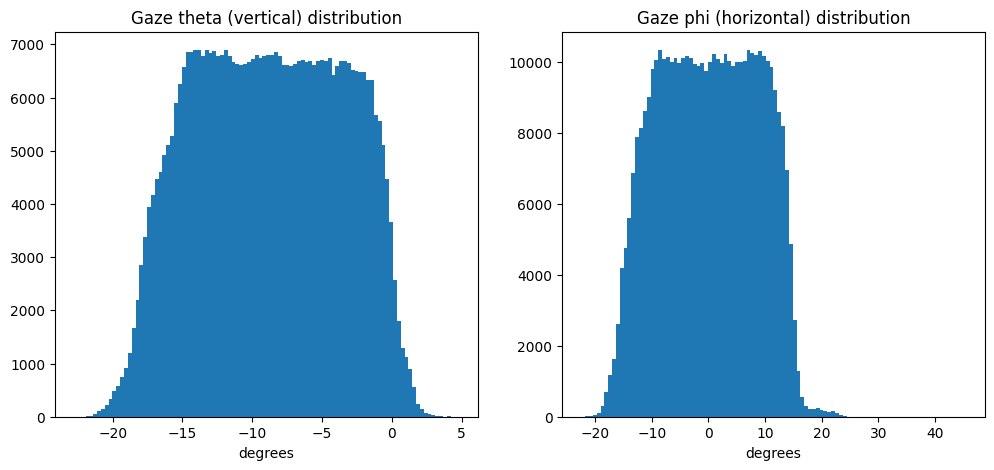

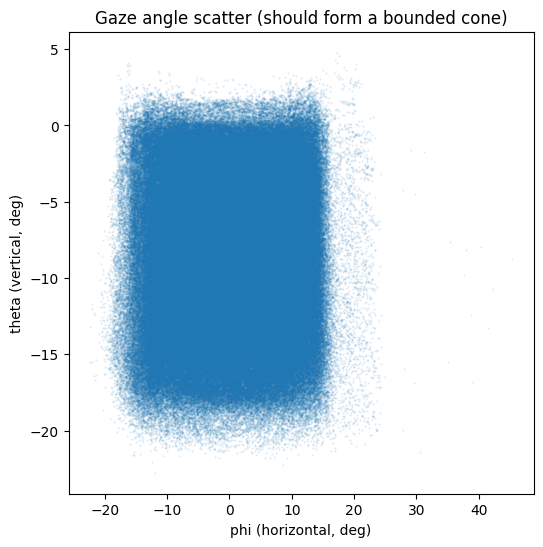

theta range: -0.3973060019861214 0.08312640182428395
phi range: -0.39181630616037827 0.7927781996478728


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(np.degrees(gaze[:, 0]), bins=100)
axes[0].set_title("Gaze theta (vertical) distribution")
axes[0].set_xlabel("degrees")

axes[1].hist(np.degrees(gaze[:, 1]), bins=100)
axes[1].set_title("Gaze phi (horizontal) distribution")
axes[1].set_xlabel("degrees")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(np.degrees(gaze[:, 1]), np.degrees(gaze[:, 0]), s=0.5, alpha=0.1)
plt.xlabel("phi (horizontal, deg)")
plt.ylabel("theta (vertical, deg)")
plt.title("Gaze angle scatter (should form a bounded cone)")
plt.show()

print("theta range:", gaze[:,0].min(), gaze[:,0].max())
print("phi range:", gaze[:,1].min(), gaze[:,1].max())


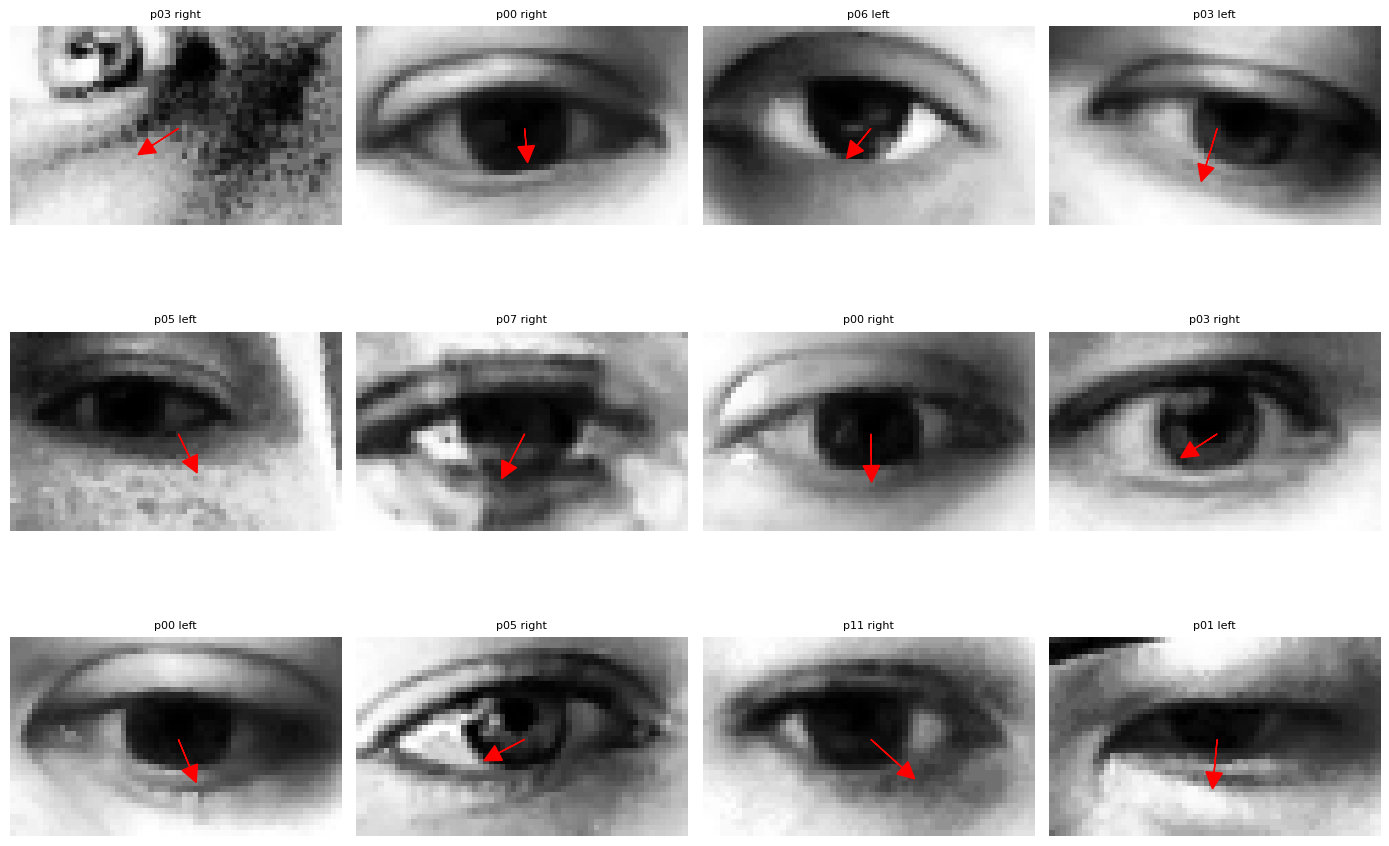

In [11]:
import matplotlib.pyplot as plt

def draw_gaze_arrow(ax, img, theta, phi, length=25):
    ax.imshow(img, cmap='gray')
    h, w = img.shape
    cx, cy = w/2, h/2
    # project gaze angle to 2D arrow direction (phi=horizontal, theta=vertical)
    dx = length * np.sin(phi)
    dy = -length * np.sin(theta)  # negative because image y grows downward
    ax.arrow(cx, cy, dx, dy, color='red', head_width=3, head_length=3)
    ax.axis('off')

rng = np.random.default_rng(42)
idx = rng.choice(len(images), 12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, i in zip(axes.flat, idx):
    draw_gaze_arrow(ax, images[i], gaze[i,0], gaze[i,1])
    ax.set_title(f"{participant[i]} {eye_side[i]}", fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
import cv2

def pupil_offset(img, thresh_percentile=15):
    thresh = np.percentile(img, thresh_percentile)
    dark_mask = (img < thresh).astype(np.uint8)
    ys, xs = np.where(dark_mask)
    if len(xs) < 5:
        return None
    h, w = img.shape
    cx, cy = xs.mean() - w/2, ys.mean() - h/2
    return cx, cy

# sample a subset for speed
rng = np.random.default_rng(0)
idx = rng.choice(len(images), 5000, replace=False)

offsets_x, offsets_y = [], []
gazes_theta, gazes_phi = [], []

for i in idx:
    off = pupil_offset(images[i])
    if off is None:
        continue
    offsets_x.append(off[0])
    offsets_y.append(off[1])
    gazes_theta.append(gaze[i, 0])
    gazes_phi.append(gaze[i, 1])

offsets_x = np.array(offsets_x)
offsets_y = np.array(offsets_y)
gazes_theta = np.array(gazes_theta)
gazes_phi = np.array(gazes_phi)

corr_x_phi = np.corrcoef(offsets_x, gazes_phi)[0,1]
corr_y_theta = np.corrcoef(offsets_y, gazes_theta)[0,1]

print(f"correlation(pupil_x_offset, phi):   {corr_x_phi:.3f}")
print(f"correlation(pupil_y_offset, theta): {corr_y_theta:.3f}")

correlation(pupil_x_offset, phi):   -0.106
correlation(pupil_y_offset, theta): -0.190


In [13]:
import cv2

def pupil_offset_v2(img, thresh_percentile=20):
    """Find the largest dark blob near image center — more robust than raw threshold."""
    thresh = np.percentile(img, thresh_percentile)
    mask = (img < thresh).astype(np.uint8)

    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if n_labels <= 1:
        return None

    h, w = img.shape
    cx_img, cy_img = w / 2, h / 2

    # pick the blob closest to image center among reasonably-sized blobs (skip background label 0)
    best = None
    best_dist = None
    for i in range(1, n_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area < 15:  # too small, likely noise
            continue
        cx, cy = centroids[i]
        dist = (cx - cx_img)**2 + (cy - cy_img)**2
        if best_dist is None or dist < best_dist:
            best_dist = dist
            best = (cx - cx_img, cy - cy_img)

    return best

rng = np.random.default_rng(0)
idx = rng.choice(len(images), 5000, replace=False)

offsets_x, offsets_y = [], []
valid_idx = []

for i in idx:
    off = pupil_offset_v2(images[i])
    if off is None:
        continue
    offsets_x.append(off[0])
    offsets_y.append(off[1])
    valid_idx.append(i)

offsets_x = np.array(offsets_x)
offsets_y = np.array(offsets_y)
valid_idx = np.array(valid_idx)

print(f"Valid samples: {len(offsets_x)} / 5000")

Valid samples: 4994 / 5000


In [14]:
print("Original:")
print(f"  corr(offset_x, phi):   {np.corrcoef(offsets_x, gazes_phi)[0,1]:.3f}")
print(f"  corr(offset_y, theta): {np.corrcoef(offsets_y, gazes_theta)[0,1]:.3f}")

print("Flip x only:")
print(f"  corr(-offset_x, phi):  {np.corrcoef(-offsets_x, gazes_phi)[0,1]:.3f}")

print("Flip y only:")
print(f"  corr(-offset_y, theta): {np.corrcoef(-offsets_y, gazes_theta)[0,1]:.3f}")

Original:
  corr(offset_x, phi):   -0.199
  corr(offset_y, theta): -0.140
Flip x only:
  corr(-offset_x, phi):  0.199
Flip y only:
  corr(-offset_y, theta): 0.140


In [15]:
# take samples with extreme phi (clear left vs right gaze) and compare mean pupil x-offset
phi_median = np.median(gazes_phi)
low_phi_mask = gazes_phi < np.percentile(gazes_phi, 20)   # most "left"-looking
high_phi_mask = gazes_phi > np.percentile(gazes_phi, 80)  # most "right"-looking

print(f"Mean pupil x-offset, LOW phi group:  {offsets_x[low_phi_mask].mean():.3f}")
print(f"Mean pupil x-offset, HIGH phi group: {offsets_x[high_phi_mask].mean():.3f}")

theta_median = np.median(gazes_theta)
low_theta_mask = gazes_theta < np.percentile(gazes_theta, 20)
high_theta_mask = gazes_theta > np.percentile(gazes_theta, 80)

print(f"Mean pupil y-offset, LOW theta group:  {offsets_y[low_theta_mask].mean():.3f}")
print(f"Mean pupil y-offset, HIGH theta group: {offsets_y[high_theta_mask].mean():.3f}")

Mean pupil x-offset, LOW phi group:  0.889
Mean pupil x-offset, HIGH phi group: -2.616
Mean pupil y-offset, LOW theta group:  -2.421
Mean pupil y-offset, HIGH theta group: -3.556


In [16]:
gaze[:, 1] = -gaze[:, 1]
print("phi flipped. New range:", gaze[:, 1].min(), gaze[:, 1].max())

phi flipped. New range: -0.7927781996478728 0.39181630616037827


In [17]:
gaze_phi_valid = gaze[:, 1][valid_idx]

low_phi_mask = gaze_phi_valid < np.percentile(gaze_phi_valid, 20)
high_phi_mask = gaze_phi_valid > np.percentile(gaze_phi_valid, 80)

print(f"Mean pupil x-offset, LOW phi:  {offsets_x[low_phi_mask].mean():.3f}")
print(f"Mean pupil x-offset, HIGH phi: {offsets_x[high_phi_mask].mean():.3f}")

Mean pupil x-offset, LOW phi:  -2.616
Mean pupil x-offset, HIGH phi: 0.889


In [18]:
gaze[:, 1] = -gaze[:, 1]
print("phi flipped. New range:", gaze[:, 1].min(), gaze[:, 1].max())

phi flipped. New range: -0.39181630616037827 0.7927781996478728


In [19]:
gaze_phi_valid = gaze[:, 1][valid_idx]

low_phi_mask = gaze_phi_valid < np.percentile(gaze_phi_valid, 20)
high_phi_mask = gaze_phi_valid > np.percentile(gaze_phi_valid, 80)

print(f"Mean pupil x-offset, LOW phi:  {offsets_x[low_phi_mask].mean():.3f}")
print(f"Mean pupil x-offset, HIGH phi: {offsets_x[high_phi_mask].mean():.3f}")

Mean pupil x-offset, LOW phi:  0.889
Mean pupil x-offset, HIGH phi: -2.616


In [20]:
np.savez_compressed(
    '/content/drive/MyDrive/EyeTracker/Data/mpiigaze_raw.npz',
    images=images, gaze=gaze, pose=pose,
    eye_side=eye_side, participant=participant, day=day
)
print("Saved corrected checkpoint to Drive (phi sign fixed)")

Saved corrected checkpoint to Drive (phi sign fixed)


In [21]:
import cv2
from tqdm import tqdm

blur_scores = np.zeros(len(images), dtype=np.float32)
brightness_scores = np.zeros(len(images), dtype=np.float32)

batch_size = 10000
for start in tqdm(range(0, len(images), batch_size)):
    end = min(start + batch_size, len(images))
    for i in range(start, end):
        img = images[i]
        blur_scores[i] = cv2.Laplacian(img, cv2.CV_64F).var()
        brightness_scores[i] = img.mean()

print("Blur score stats:", blur_scores.min(), blur_scores.mean(), blur_scores.max())
print("Brightness stats:", brightness_scores.min(), brightness_scores.mean(), brightness_scores.max())

100%|██████████| 43/43 [00:53<00:00,  1.23s/it]

Blur score stats: 50.933285 1521.9827 81084.164
Brightness stats: 40.63148 128.91783 219.89954


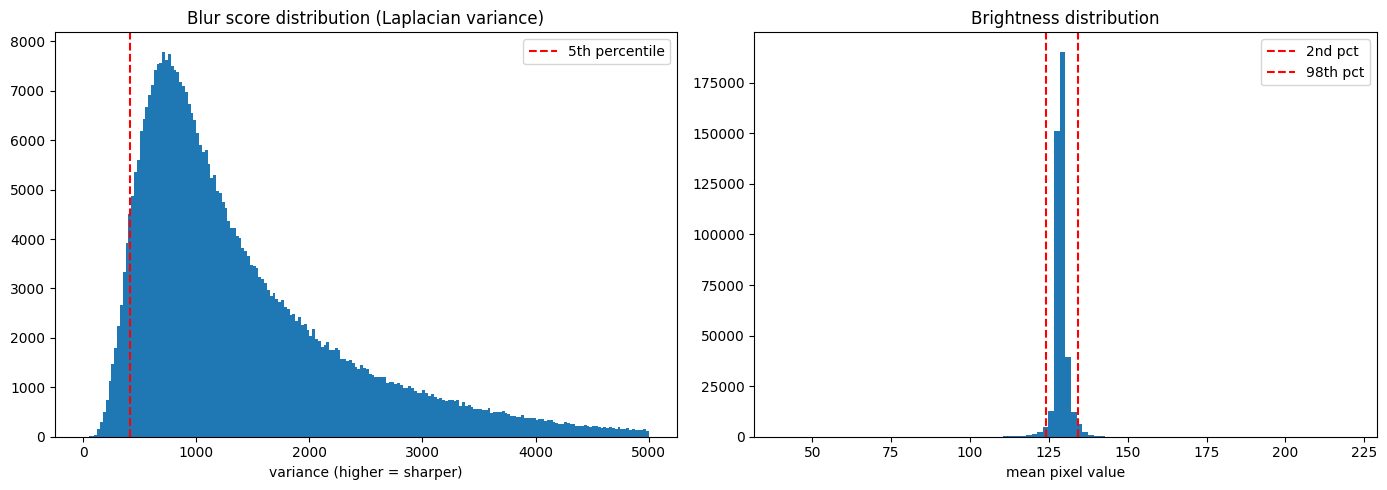

Blur percentiles: {1: np.float32(273.6866), 5: np.float32(417.07483), 10: np.float32(516.43085), 25: np.float32(739.9127), 50: np.float32(1142.0555)}
Brightness percentiles: {1: np.float32(122.072426), 2: np.float32(124.239815), 5: np.float32(126.486115), 95: np.float32(132.16667), 98: np.float32(134.27916), 99: np.float32(135.58047)}


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(blur_scores, bins=200, range=(0, 5000))
axes[0].set_title("Blur score distribution (Laplacian variance)")
axes[0].set_xlabel("variance (higher = sharper)")
axes[0].axvline(np.percentile(blur_scores, 5), color='red', linestyle='--', label='5th percentile')
axes[0].legend()

axes[1].hist(brightness_scores, bins=100)
axes[1].set_title("Brightness distribution")
axes[1].set_xlabel("mean pixel value")
axes[1].axvline(np.percentile(brightness_scores, 2), color='red', linestyle='--', label='2nd pct')
axes[1].axvline(np.percentile(brightness_scores, 98), color='red', linestyle='--', label='98th pct')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Blur percentiles:", {p: np.percentile(blur_scores, p) for p in [1, 5, 10, 25, 50]})
print("Brightness percentiles:", {p: np.percentile(brightness_scores, p) for p in [1, 2, 5, 95, 98, 99]})

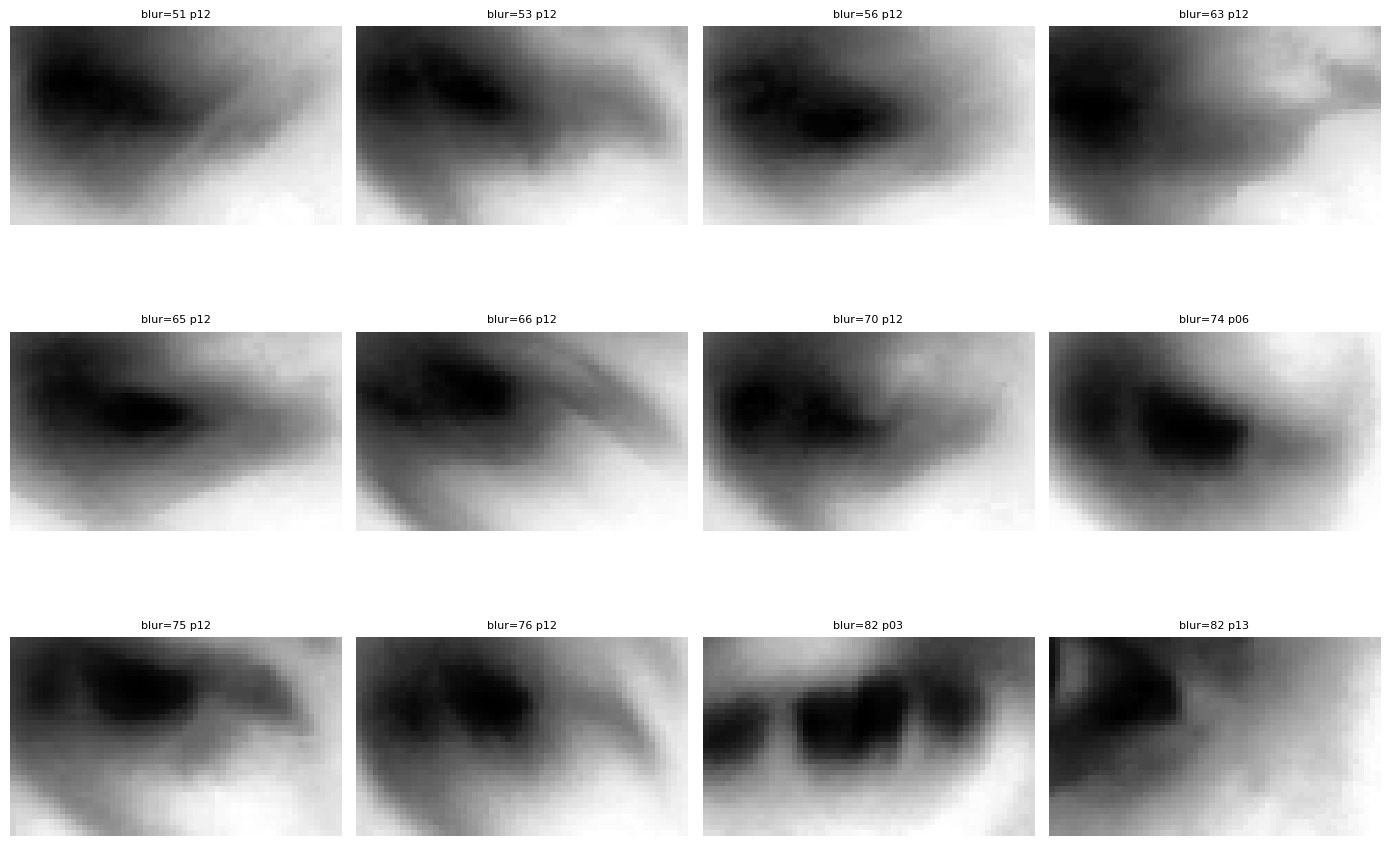

In [23]:
worst_blur_idx = np.argsort(blur_scores)[:12]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, i in zip(axes.flat, worst_blur_idx):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"blur={blur_scores[i]:.0f} {participant[i]}", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [24]:
blur_cutoff = np.percentile(blur_scores, 2)
keep_mask = blur_scores > blur_cutoff

print(f"Blur cutoff: {blur_cutoff:.1f}")
print(f"Keeping {keep_mask.sum()} / {len(keep_mask)} samples ({100*keep_mask.mean():.1f}%)")

# per-participant survival check — make sure no participant gets disproportionately wiped
import pandas as pd
df_check = pd.DataFrame({'participant': participant, 'keep': keep_mask})
print(df_check.groupby('participant')['keep'].agg(['sum', 'count', 'mean']))

Blur cutoff: 326.5
Keeping 418769 / 427316 samples (98.0%)
               sum  count      mean
participant                        
p00          59118  59922  0.986583
p01          48247  48286  0.999192
p02          54788  56038  0.977694
p03          68657  70150  0.978717
p04          33661  33662  0.999970
p05          32955  33154  0.993998
p06          34872  36896  0.945143
p07          31002  31018  0.999484
p08          21316  21402  0.995982
p09          15966  15990  0.998499
p10           5609   5620  0.998043
p11           4991   5964  0.836854
p12           2058   3218  0.639528
p13           2530   2996  0.844459
p14           2999   3000  0.999667


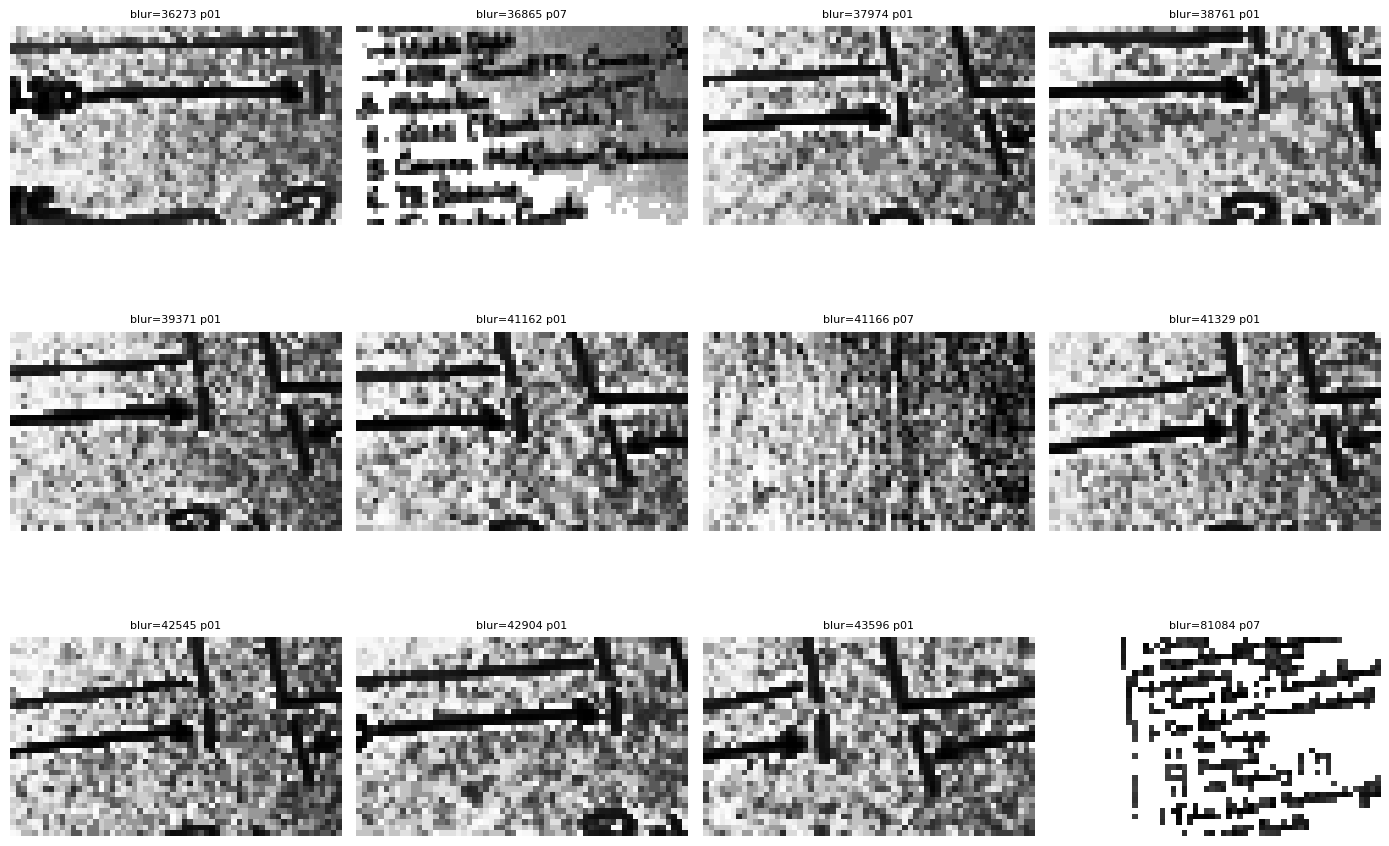

In [25]:
worst_blur_idx_high = np.argsort(blur_scores)[-12:]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, i in zip(axes.flat, worst_blur_idx_high):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"blur={blur_scores[i]:.0f} {participant[i]}", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

Percentiles at the high end:
  99: 5950
  99.5: 7275
  99.8: 10605
  99.9: 15773
  99.95: 21620
  99.99: 30102


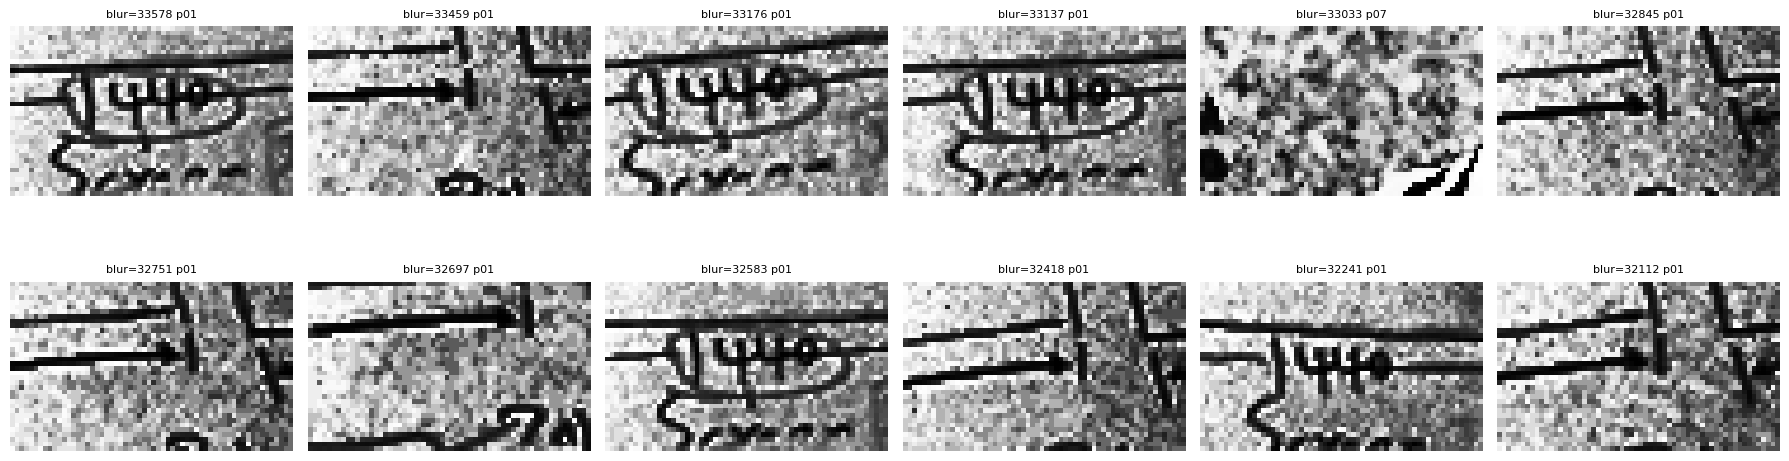

In [26]:
# check the shape of the tail before picking a threshold
print("Percentiles at the high end:")
for p in [99, 99.5, 99.8, 99.9, 99.95, 99.99]:
    print(f"  {p}: {np.percentile(blur_scores, p):.0f}")

# visualize where corruption starts
sorted_idx = np.argsort(blur_scores)[::-1]
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for ax, i in zip(axes.flat, sorted_idx[20:32]):  # skip the worst 20 (already confirmed garbage), check just below
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"blur={blur_scores[i]:.0f} {participant[i]}", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [27]:
high_cutoff = 30000  # placeholder, adjust based on Cell 19 output
low_cutoff = np.percentile(blur_scores, 2)

keep_mask = (blur_scores > low_cutoff) & (blur_scores < high_cutoff)
print(f"Keeping {keep_mask.sum()} / {len(keep_mask)} ({100*keep_mask.mean():.1f}%)")

df_check = pd.DataFrame({'participant': participant, 'keep': keep_mask})
print(df_check.groupby('participant')['keep'].agg(['sum', 'count', 'mean']))

Keeping 418725 / 427316 (98.0%)
               sum  count      mean
participant                        
p00          59118  59922  0.986583
p01          48207  48286  0.998364
p02          54788  56038  0.977694
p03          68657  70150  0.978717
p04          33661  33662  0.999970
p05          32955  33154  0.993998
p06          34872  36896  0.945143
p07          30998  31018  0.999355
p08          21316  21402  0.995982
p09          15966  15990  0.998499
p10           5609   5620  0.998043
p11           4991   5964  0.836854
p12           2058   3218  0.639528
p13           2530   2996  0.844459
p14           2999   3000  0.999667


In [28]:
# scan deeper into the sorted list, jump in bigger steps
sorted_idx = np.argsort(blur_scores)[::-1]

for rank in [50, 100, 200, 500, 1000, 2000, 5000]:
    i = sorted_idx[rank]
    print(f"rank {rank}: blur={blur_scores[i]:.0f}, participant={participant[i]}")

rank 50: blur=29463, participant=p01
rank 100: blur=26277, participant=p01
rank 200: blur=21876, participant=p01
rank 500: blur=14655, participant=p02
rank 1000: blur=9682, participant=p04
rank 2000: blur=7433, participant=p04
rank 5000: blur=5719, participant=p03


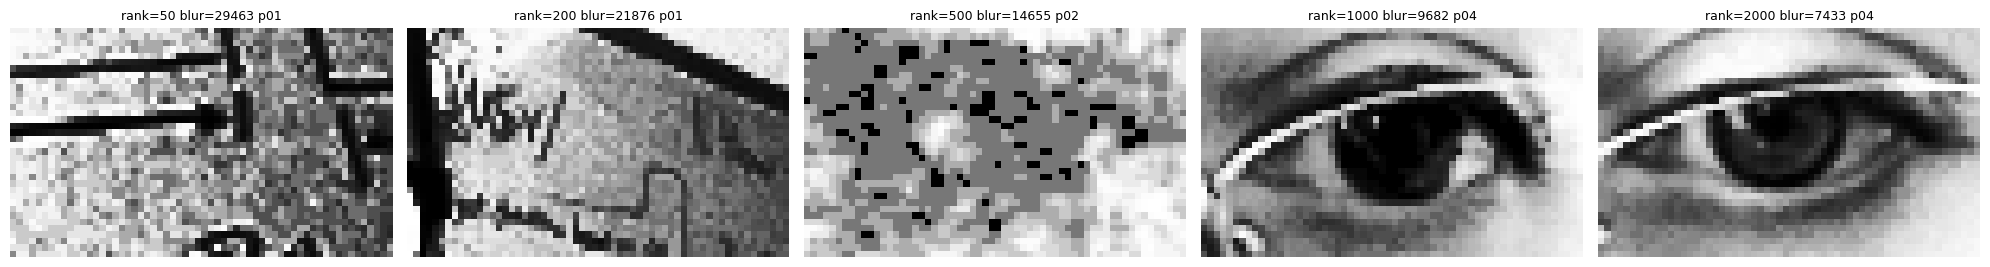

In [29]:
check_ranks = [50, 200, 500, 1000, 2000]
fig, axes = plt.subplots(1, len(check_ranks), figsize=(4*len(check_ranks), 4))
for ax, rank in zip(axes, check_ranks):
    i = sorted_idx[rank]
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"rank={rank} blur={blur_scores[i]:.0f} {participant[i]}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [30]:
# count how many high-blur (>15000, clearly in corrupted territory based on what we've seen) samples per participant
high_blur_mask = blur_scores > 15000
df_high = pd.DataFrame({'participant': participant, 'is_corrupted': high_blur_mask})
print(df_high.groupby('participant')['is_corrupted'].agg(['sum', 'count', 'mean']))

             sum  count      mean
participant                      
p00            1  59922  0.000017
p01          342  48286  0.007083
p02            2  56038  0.000036
p03           82  70150  0.001169
p04           17  33662  0.000505
p05            2  33154  0.000060
p06            4  36896  0.000108
p07           22  31018  0.000709
p08            3  21402  0.000140
p09            0  15990  0.000000
p10            0   5620  0.000000
p11            1   5964  0.000168
p12            0   3218  0.000000
p13            0   2996  0.000000
p14            0   3000  0.000000


In [31]:
low_cutoff = np.percentile(blur_scores, 2)
high_cutoff = 15000

keep_mask = (blur_scores > low_cutoff) & (blur_scores < high_cutoff)
print(f"Low cutoff: {low_cutoff:.1f}, High cutoff: {high_cutoff}")
print(f"Keeping {keep_mask.sum()} / {len(keep_mask)} ({100*keep_mask.mean():.1f}%)")

df_check = pd.DataFrame({'participant': participant, 'keep': keep_mask})
print(df_check.groupby('participant')['keep'].agg(['sum', 'count', 'mean']))

Low cutoff: 326.5, High cutoff: 15000
Keeping 418293 / 427316 (97.9%)
               sum  count      mean
participant                        
p00          59117  59922  0.986566
p01          47905  48286  0.992110
p02          54786  56038  0.977658
p03          68575  70150  0.977548
p04          33644  33662  0.999465
p05          32953  33154  0.993937
p06          34868  36896  0.945035
p07          30980  31018  0.998775
p08          21313  21402  0.995842
p09          15966  15990  0.998499
p10           5609   5620  0.998043
p11           4990   5964  0.836687
p12           2058   3218  0.639528
p13           2530   2996  0.844459
p14           2999   3000  0.999667


In [32]:
# Does gaze angle distribution differ wildly per participant? (expected to differ some — camera position varies)
df_bias = pd.DataFrame({
    'participant': participant[keep_mask],
    'theta': gaze[keep_mask, 0],
    'phi': gaze[keep_mask, 1],
    'pose_theta': pose[keep_mask, 0],
    'pose_phi': pose[keep_mask, 1],
})

print(df_bias.groupby('participant')[['theta', 'phi']].agg(['mean', 'std']))

# head pose vs gaze correlation
print("\ncorr(pose_theta, gaze_theta):", np.corrcoef(df_bias['pose_theta'], df_bias['theta'])[0,1])
print("corr(pose_phi, gaze_phi):", np.corrcoef(df_bias['pose_phi'], df_bias['phi'])[0,1])


                theta                 phi          
                 mean       std      mean       std
participant                                        
p00         -0.132823  0.079836  0.044162  0.132642
p01         -0.167253  0.084891  0.018793  0.138980
p02         -0.121160  0.086478  0.002919  0.141369
p03         -0.161480  0.094311 -0.008150  0.155476
p04         -0.151427  0.088486 -0.025841  0.144235
p05         -0.153951  0.091403 -0.064438  0.148340
p06         -0.175655  0.099725 -0.000352  0.165589
p07         -0.168425  0.091478  0.029195  0.156423
p08         -0.172575  0.092682 -0.053733  0.149132
p09         -0.156910  0.088146 -0.012285  0.145074
p10         -0.155842  0.085277 -0.005672  0.141489
p11         -0.156215  0.084153  0.012806  0.136345
p12         -0.130366  0.083792  0.009021  0.138910
p13         -0.149211  0.084981  0.017709  0.147701
p14         -0.122366  0.098090  0.085462  0.161653

corr(pose_theta, gaze_theta): -0.04077917960750158
corr(pose_ph

## Test Training Split

In [33]:
# 15 participants total. Reserve smaller/lower-quality ones for test, not train.
test_participants = ['p12']          # lowest quality — good held-out test of robustness, or could exclude entirely
val_participants = ['p13', 'p09']    # moderate size, held out for validation
train_participants = [p for p in participants if p not in test_participants + val_participants]

print("Train:", train_participants)
print("Val:", val_participants)
print("Test:", test_participants)

def participant_mask(plist):
    return np.isin(participant, plist) & keep_mask

train_mask = participant_mask(train_participants)
val_mask = participant_mask(val_participants)
test_mask = participant_mask(test_participants)

print(f"\nTrain: {train_mask.sum()} samples")
print(f"Val:   {val_mask.sum()} samples")
print(f"Test:  {test_mask.sum()} samples")

Train: ['p00', 'p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p10', 'p11', 'p14']
Val: ['p13', 'p09']
Test: ['p12']

Train: 397739 samples
Val:   18496 samples
Test:  2058 samples


In [34]:
test_participants = ['p12']
val_participants = ['p13', 'p09']
train_participants = [p for p in participants if p not in test_participants + val_participants]

print("Train:", train_participants)
print("Val:", val_participants)
print("Test:", test_participants)

def participant_mask(plist):
    return np.isin(participant, plist) & keep_mask

train_mask = participant_mask(train_participants)
val_mask = participant_mask(val_participants)
test_mask = participant_mask(test_participants)

print(f"\nTrain: {train_mask.sum()} samples")
print(f"Val:   {val_mask.sum()} samples")
print(f"Test:  {test_mask.sum()} samples")

Train: ['p00', 'p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p10', 'p11', 'p14']
Val: ['p13', 'p09']
Test: ['p12']

Train: 397739 samples
Val:   18496 samples
Test:  2058 samples


**Saving Splits to Drive**


In [35]:
np.savez_compressed(
    '/content/drive/MyDrive/EyeTracker/Data/mpiigaze_train.npz',
    images=images[train_mask], gaze=gaze[train_mask],
    eye_side=eye_side[train_mask], participant=participant[train_mask]
)
print("Train saved:", train_mask.sum(), "samples")

np.savez_compressed(
    '/content/drive/MyDrive/EyeTracker/Data/mpiigaze_val.npz',
    images=images[val_mask], gaze=gaze[val_mask],
    eye_side=eye_side[val_mask], participant=participant[val_mask]
)
print("Val saved:", val_mask.sum(), "samples")

np.savez_compressed(
    '/content/drive/MyDrive/EyeTracker/Data/mpiigaze_test.npz',
    images=images[test_mask], gaze=gaze[test_mask],
    eye_side=eye_side[test_mask], participant=participant[test_mask]
)
print("Test saved:", test_mask.sum(), "samples")

Train saved: 397739 samples
Val saved: 18496 samples
Test saved: 2058 samples


## **Phase 5** — CNN gaze regression model. Let's build this in pieces:<br> Dataset class → model → training loop.

In [36]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

class GazeDataset(Dataset):
    def __init__(self, npz_path, augment=False):
        data = np.load(npz_path)
        self.images = data['images']   # (N, 36, 60) uint8
        self.gaze = data['gaze'].astype(np.float32)  # (N, 2) theta, phi
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32) / 255.0  # normalize to [0,1]

        if self.augment:
            # mild brightness jitter — helps generalize to webcam lighting variation
            if np.random.rand() < 0.5:
                img = np.clip(img * np.random.uniform(0.8, 1.2), 0, 1)
            # small horizontal flip is INVALID here — it would flip gaze direction
            # without also flipping the label, so we skip flip augmentation entirely

        img = torch.from_numpy(img).unsqueeze(0)  # (1, 36, 60)
        gaze = torch.from_numpy(self.gaze[idx])    # (2,)
        return img, gaze

train_ds = GazeDataset('/content/drive/MyDrive/EyeTracker/Data/mpiigaze_train.npz', augment=True)
val_ds = GazeDataset('/content/drive/MyDrive/EyeTracker/Data/mpiigaze_val.npz', augment=False)
test_ds = GazeDataset('/content/drive/MyDrive/EyeTracker/Data/mpiigaze_test.npz', augment=False)

print(len(train_ds), len(val_ds), len(test_ds))

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

397739 18496 2058


**Model Architecture**

In [37]:
class GazeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),  # 18x30

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),  # 9x15

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((3, 5)),  # fixed size regardless of input variation
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 5, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 2)  # theta, phi
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = GazeCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

Using device: cuda
Model parameters: 393,762


**Check if GPU working**

In [38]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

True
Tesla T4


### Training loop with angular error in degrees

In [39]:
def angular_error_deg(pred, target):
    """Mean angular error in degrees, per-axis average (simple proxy metric)."""
    diff = (pred - target).abs()
    return torch.rad2deg(diff).mean().item()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

n_epochs = 20
best_val_loss = float('inf')

for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    for imgs, gazes in train_loader:
        imgs, gazes = imgs.to(device), gazes.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, gazes)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_ds)

    model.eval()
    val_loss = 0
    val_ang_err = 0
    with torch.no_grad():
        for imgs, gazes in val_loader:
            imgs, gazes = imgs.to(device), gazes.to(device)
            preds = model(imgs)
            loss = criterion(preds, gazes)
            val_loss += loss.item() * imgs.size(0)
            val_ang_err += angular_error_deg(preds, gazes) * imgs.size(0)
    val_loss /= len(val_ds)
    val_ang_err /= len(val_ds)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{n_epochs} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f} | val_ang_err={val_ang_err:.2f}° | lr={current_lr:.1e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/EyeTracker/Data/best_gaze_model.pt')
        print("  -> saved new best model")

Epoch 1/20 | train_loss=0.00391 | val_loss=0.00742 | val_ang_err=4.02° | lr=1.0e-03
  -> saved new best model
Epoch 2/20 | train_loss=0.00215 | val_loss=0.00729 | val_ang_err=4.00° | lr=1.0e-03
  -> saved new best model
Epoch 3/20 | train_loss=0.00183 | val_loss=0.00666 | val_ang_err=3.81° | lr=1.0e-03
  -> saved new best model
Epoch 4/20 | train_loss=0.00164 | val_loss=0.00743 | val_ang_err=4.04° | lr=1.0e-03
Epoch 5/20 | train_loss=0.00151 | val_loss=0.00692 | val_ang_err=3.87° | lr=1.0e-03
Epoch 6/20 | train_loss=0.00140 | val_loss=0.00656 | val_ang_err=3.77° | lr=1.0e-03
  -> saved new best model
Epoch 7/20 | train_loss=0.00133 | val_loss=0.00687 | val_ang_err=3.87° | lr=1.0e-03
Epoch 8/20 | train_loss=0.00126 | val_loss=0.00692 | val_ang_err=3.87° | lr=1.0e-03
Epoch 9/20 | train_loss=0.00120 | val_loss=0.00692 | val_ang_err=3.86° | lr=5.0e-04
Epoch 10/20 | train_loss=0.00103 | val_loss=0.00702 | val_ang_err=3.87° | lr=5.0e-04
Epoch 11/20 | train_loss=0.00099 | val_loss=0.00712 | v

### Load to Check

In [40]:
model.load_state_dict(torch.load('/content/drive/MyDrive/EyeTracker/Data/best_gaze_model.pt'))
model.eval()

test_loss = 0
test_ang_err = 0
with torch.no_grad():
    for imgs, gazes in test_loader:
        imgs, gazes = imgs.to(device), gazes.to(device)
        preds = model(imgs)
        loss = criterion(preds, gazes)
        test_loss += loss.item() * imgs.size(0)
        test_ang_err += angular_error_deg(preds, gazes) * imgs.size(0)

test_loss /= len(test_ds)
test_ang_err /= len(test_ds)
print(f"Test loss: {test_loss:.5f} | Test angular error: {test_ang_err:.2f}°")

Test loss: 0.00602 | Test angular error: 3.58°


### Predicted vs actual gaze arrows on test set

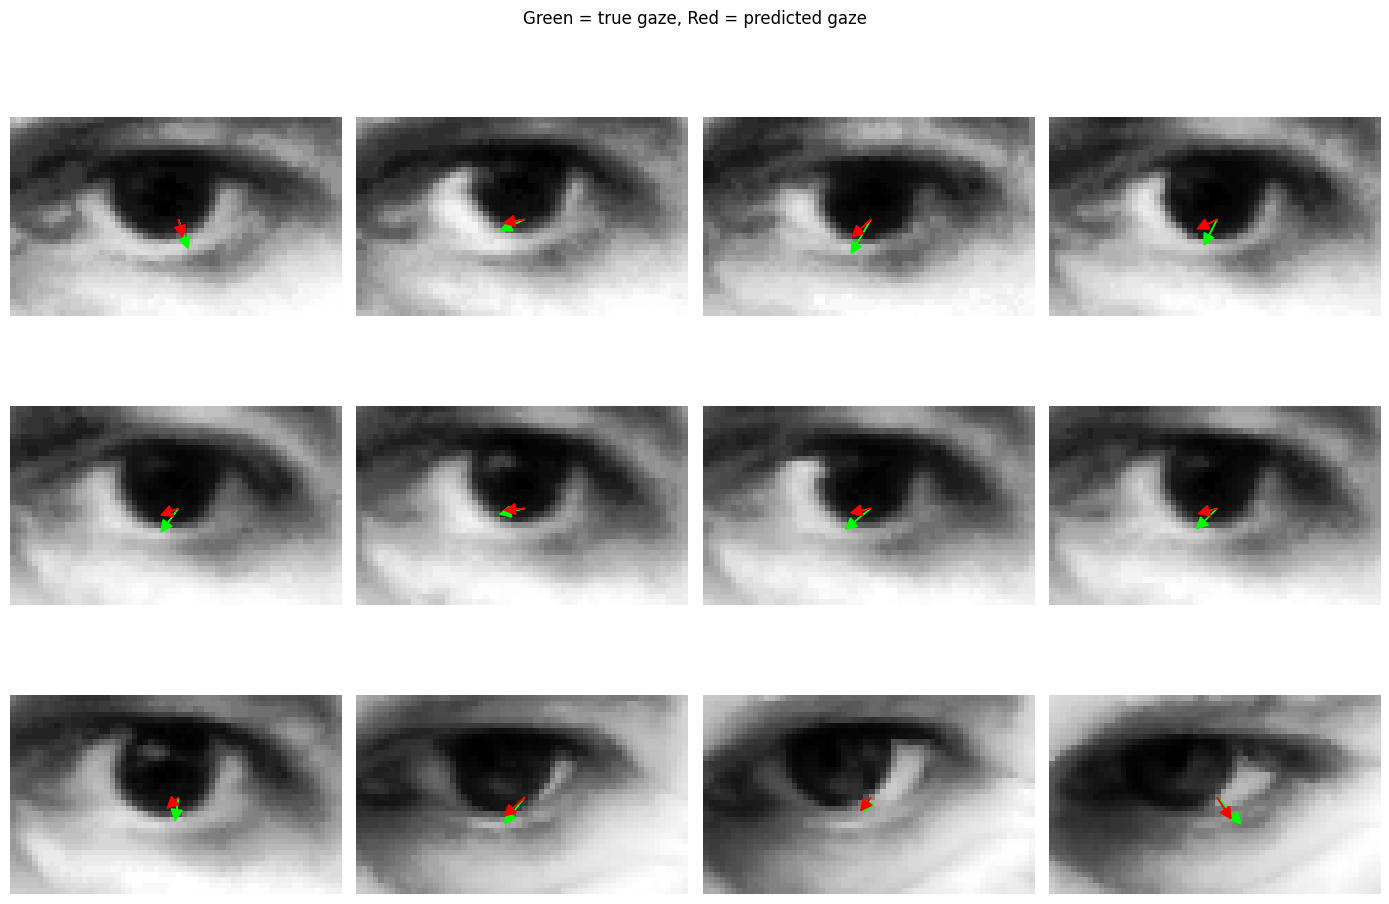

In [41]:
model.eval()
imgs_batch, gazes_batch = next(iter(test_loader))
imgs_batch, gazes_batch = imgs_batch.to(device), gazes_batch.to(device)

with torch.no_grad():
    preds_batch = model(imgs_batch)

imgs_np = imgs_batch.cpu().numpy()
gazes_np = gazes_batch.cpu().numpy()
preds_np = preds_batch.cpu().numpy()

def draw_two_arrows(ax, img, true_angle, pred_angle, length=15):
    ax.imshow(img.squeeze(), cmap='gray')
    h, w = img.shape[1], img.shape[2]
    cx, cy = w/2, h/2

    dx_t = length * np.sin(true_angle[1])
    dy_t = -length * np.sin(true_angle[0])
    ax.arrow(cx, cy, dx_t, dy_t, color='lime', head_width=2, head_length=2, label='true')

    dx_p = length * np.sin(pred_angle[1])
    dy_p = -length * np.sin(pred_angle[0])
    ax.arrow(cx, cy, dx_p, dy_p, color='red', head_width=2, head_length=2, label='pred')

    ax.axis('off')

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, i in zip(axes.flat, range(12)):
    draw_two_arrows(ax, imgs_np[i], gazes_np[i], preds_np[i])

fig.suptitle("Green = true gaze, Red = predicted gaze", fontsize=12)
plt.tight_layout()
plt.show()